The aim of the code below is to calculate the base MAE of the predictions that the api data has, so that I can then aim to beat it with my own model.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sqlalchemy import create_engine
import os

engine = create_engine(os.environ["DATABASE_URL"])

query = """
SELECT
    p.period_from,
    p.period_to,
    nr.reading_id,
    nr.forecast_intensity,
    nr.actual_intensity
FROM national_readings nr
JOIN period_id p
    ON nr.reading_id = p.id
ORDER BY p.period_from;
"""

data = pd.read_sql(query, engine)

data["period_from"] = pd.to_datetime(data["period_from"], utc=True)
# drops readings that have a null intensity
data = data.dropna(subset=["actual_intensity"])
data.head()

data["target"] = data["actual_intensity"]

# Create a copy containing yesterday's readings
yesterday = data[
    ["period_from", "actual_intensity"]
].copy()

# Move yesterday's timestamps forward by one day
# so they line up with today's timestamps
yesterday["period_from"] = (
    yesterday["period_from"] + pd.Timedelta(days=1)
)

# Rename the intensity so we know it came from yesterday
yesterday = yesterday.rename(
    columns={
        "actual_intensity": "yesterday_intensity"
    }
)

# Match today's timestamp with the exact same time yesterday
data = data.merge(
    yesterday,
    on="period_from",
    how="left"
)



In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

baseline = data.dropna(
    subset=["actual_intensity", "yesterday_intensity"]
).copy()

baseline_mae = mean_absolute_error(
    baseline["actual_intensity"],
    baseline["yesterday_intensity"]
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        baseline["actual_intensity"],
        baseline["yesterday_intensity"]
    )
)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)

Baseline MAE: 28.454545454545453
Baseline RMSE: 30.729020929289746


In [10]:
data["hour"] = data["period_from"].dt.hour
data["minute"] = data["period_from"].dt.minute
data["day_of_week"] = data["period_from"].dt.dayofweek
data["is_weekend"] = (data["day_of_week"] >= 5).astype(int)

data["time_of_day"] = (
    data["hour"] * 2
    + (data["minute"] // 30)
)
data["previous_intensity"] = (
    data["actual_intensity"].shift(1)
)
data["intensity_2_periods_ago"] = (
    data["actual_intensity"].shift(2)
)

data["intensity_3_periods_ago"] = (
    data["actual_intensity"].shift(3)
)

features = [
    "forecast_intensity",
    "yesterday_intensity",
    "previous_intensity",
    "intensity_2_periods_ago",
    "intensity_3_periods_ago",
    "hour",
    "minute",
    "day_of_week",
    "is_weekend",
    "time_of_day"
]

X = data[features]
y = data["target"]

# remove rows where there is not enough historical information

model_data = data.dropna(
    subset=features + ["target"]
).copy()

X = model_data[features]
y = model_data["target"]

split = int(len(model_data) * 0.8)

train = model_data.iloc[:split]
test = model_data.iloc[split:]

X_train = train[features]
y_train = train["target"]

X_test = test[features]
y_test = test["target"]

In [11]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    objective="reg:squarederror",
    random_state=42
)

model.fit(
    X_train,
    y_train
)

predictions = model.predict(X_test)

results = pd.DataFrame({
    "actual": y_test.values,
    "predicted": predictions
})

results.head()

,actual,predicted
0,129.0,135.797287
1,131.0,135.797287
2,126.0,135.797287
3,151.0,148.909927
4,161.0,174.662918


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

print(f"XGBoost MAE: {mae:.2f}")
print(f"XGBoost RMSE: {rmse:.2f}")

XGBoost MAE: 7.43
XGBoost RMSE: 8.44


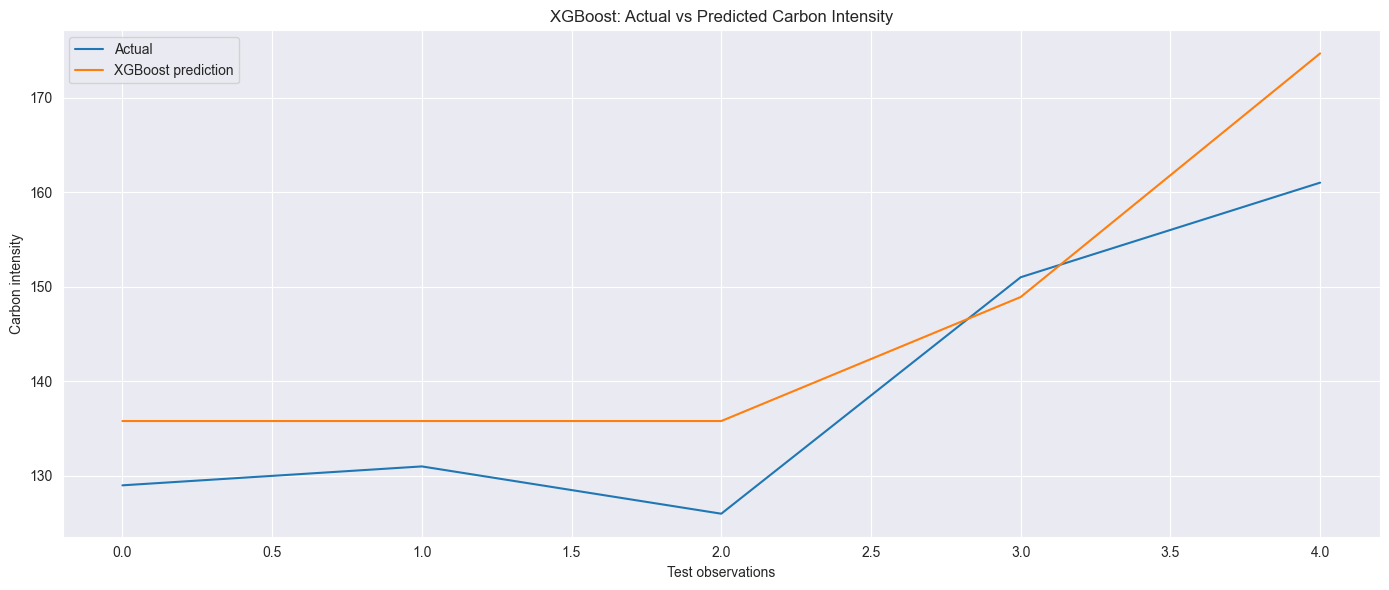

In [13]:
plt.figure(figsize=(14, 6))

plt.plot(
    y_test.values,
    label="Actual"
)

plt.plot(
    predictions,
    label="XGBoost prediction"
)

plt.xlabel("Test observations")
plt.ylabel("Carbon intensity")
plt.title("XGBoost: Actual vs Predicted Carbon Intensity")

plt.legend()
plt.tight_layout()
plt.show()

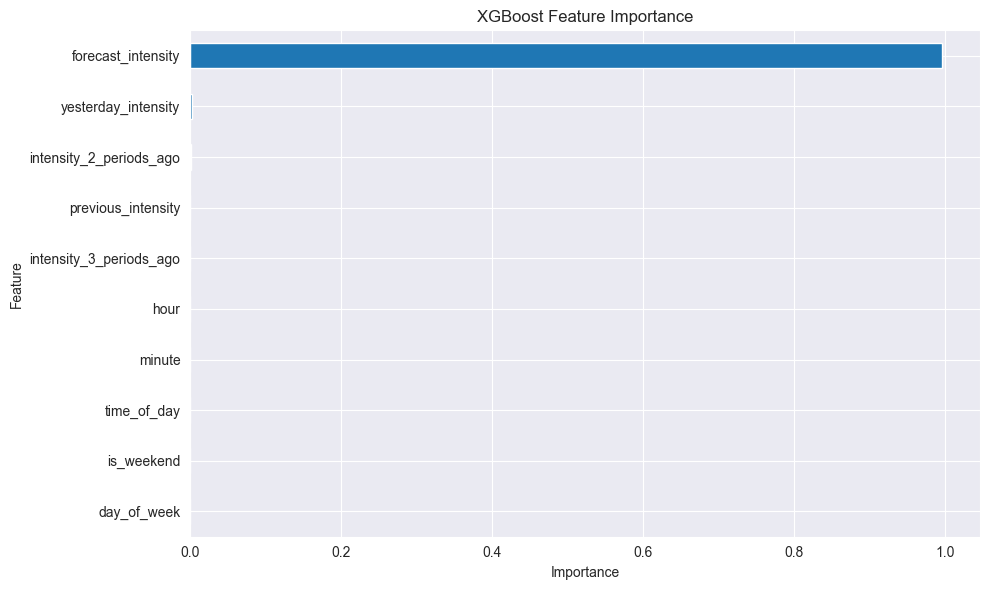

In [14]:
importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))

importance.plot(kind="barh")

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.tight_layout()
plt.show()

This is my first attempt at building a forecasting pipeline using the NESO carbon intensity data. I have established a historical baseline to compare against and have then trained an XGBoost model to investigate if adding temporal and generation mix features could improve forecast accuracy.